# Sparsemax Attention

**Sparse attention via simplex projection** — replace softmax with sparsemax to get exact-zero attention weights, then train an attention model that learns to focus on signal tokens.

This notebook demonstrates:
- **Sparsemax as an optimization problem** — projecting onto the probability simplex, solved via `solver=cp.MOREAU`
- **`cvxpylayers` attention layer** — wrap the problem as a differentiable PyTorch layer backed by Moreau, train end-to-end

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import moreau
from utils.style import set_moreau_style, set_moreau_dark_style, MOREAU_COLORS

set_moreau_style()
np.random.seed(42)
torch.manual_seed(42)

## Part A: Sparsemax as Simplex Projection

**Sparsemax** (Martins & Astudillo, 2016) maps a score vector $z \in \mathbb{R}^K$ to the probability simplex by solving:

$$\text{sparsemax}(z) = \arg\min_{p \in \Delta^K} \|p - z\|^2$$

Expanding the squared norm and dropping the constant $\|z\|^2$:

$$\min_p \; \tfrac{1}{2} \|p\|^2 - z^\top p \quad \text{s.t.} \quad \mathbf{1}^\top p = 1, \; p \geq 0$$

Unlike softmax, which always assigns positive weight to every entry, sparsemax produces **exact zeros** for low-scoring entries — the solution naturally lives on a face of the simplex.

In [2]:
# --- CVXPY sparsemax solve ---
K = 8  # dimension
z = np.array([2.1, 1.8, 0.5, 0.2, -0.3, -0.5, -1.0, -1.5])

p_var = cp.Variable(K)
objective = cp.Minimize(0.5 * cp.sum_squares(p_var) - z @ p_var)
constraints = [cp.sum(p_var) == 1, p_var >= 0]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.MOREAU)

p_sparsemax = p_var.value
p_softmax = np.exp(z) / np.exp(z).sum()

print(f"Status: {prob.status}")
print(f"\n{'k':>3}  {'z_k':>8}  {'softmax':>8}  {'sparsemax':>9}")
print("-" * 34)
for k in range(K):
    print(f"{k:3d}  {z[k]:8.2f}  {p_softmax[k]:8.4f}  {p_sparsemax[k]:9.4f}")
print(f"\nSum:           {p_softmax.sum():8.4f}  {p_sparsemax.sum():9.4f}")
print(f"Zeros:         {(p_softmax < 1e-6).sum():8d}  {(p_sparsemax < 1e-6).sum():9d}")

Status: optimal

  k       z_k   softmax  sparsemax
----------------------------------
  0      2.10    0.4292     0.6500
  1      1.80    0.3180     0.3500
  2      0.50    0.0867     0.0000
  3      0.20    0.0642     0.0000
  4     -0.30    0.0389     0.0000
  5     -0.50    0.0319     0.0000
  6     -1.00    0.0193     0.0000
  7     -1.50    0.0117     0.0000

Sum:             1.0000     1.0000
Zeros:                0          6


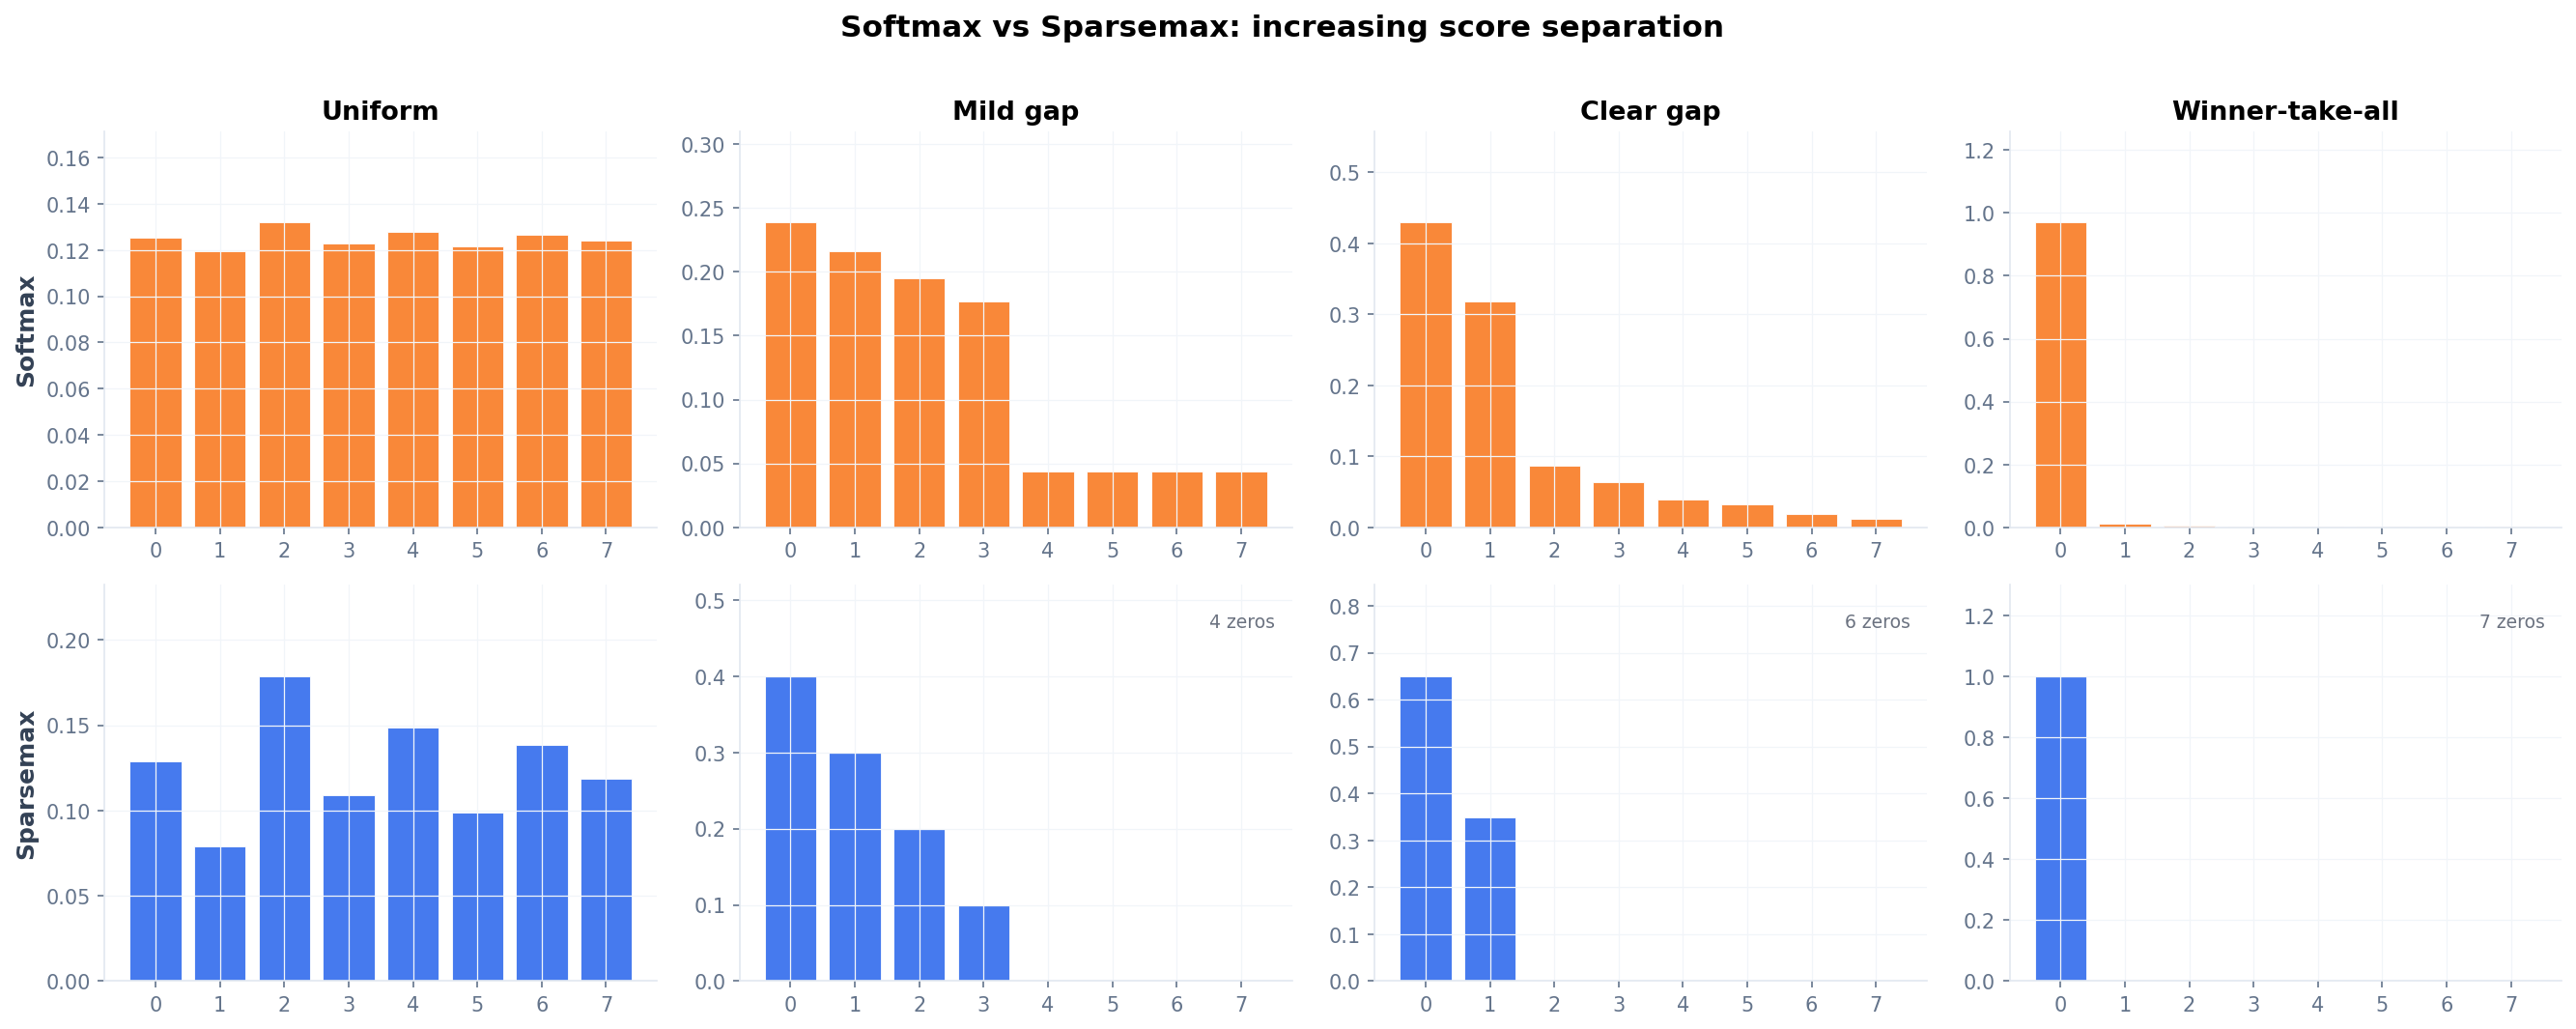

As the gap between top and bottom scores grows, sparsemax gets sparser.
Softmax never produces exact zeros.


In [3]:
# --- 2x4 grid: softmax (top) vs sparsemax (bottom) ---
# Regimes progress from no sparsity to maximum sparsity.
regimes = {
    "Uniform": np.array([1.0, 0.95, 1.05, 0.98, 1.02, 0.97, 1.01, 0.99]),
    "Mild gap": np.array([1.2, 1.1, 1.0, 0.9, -0.5, -0.5, -0.5, -0.5]),
    "Clear gap": np.array([2.1, 1.8, 0.5, 0.2, -0.3, -0.5, -1.0, -1.5]),
    "Winner-take-all": np.array([5.0, 0.5, 0.0, -0.5, -1.0, -1.0, -1.0, -1.0]),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for col, (name, z_regime) in enumerate(regimes.items()):
    # Softmax
    p_soft = np.exp(z_regime) / np.exp(z_regime).sum()

    # Sparsemax via CVXPY
    p_v = cp.Variable(K)
    prob = cp.Problem(cp.Minimize(0.5 * cp.sum_squares(p_v) - z_regime @ p_v),
                      [cp.sum(p_v) == 1, p_v >= 0])
    prob.solve(solver=cp.MOREAU)
    p_sparse = np.maximum(p_v.value, 0)

    for row, (label, probs, color) in enumerate([
        ("Softmax", p_soft, MOREAU_COLORS["accent"]),
        ("Sparsemax", p_sparse, MOREAU_COLORS["primary"]),
    ]):
        ax = axes[row, col]
        bars = ax.bar(range(K), probs, color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
        # Gray out zero entries for sparsemax
        if label == "Sparsemax":
            for k, bar in enumerate(bars):
                if probs[k] < 1e-6:
                    bar.set_color(MOREAU_COLORS["neutral_light"])
                    bar.set_alpha(0.3)
        ax.set_ylim(0, max(probs.max() * 1.3, 0.05))
        ax.set_xticks(range(K))
        if row == 0:
            ax.set_title(name, fontsize=13)
        if col == 0:
            ax.set_ylabel(label, fontsize=12, fontweight="bold")
        # Annotate sparsity
        n_zero = (probs < 1e-6).sum()
        if n_zero > 0:
            ax.text(0.97, 0.93, f"{n_zero} zeros", transform=ax.transAxes,
                    ha="right", va="top", fontsize=9, color=MOREAU_COLORS["neutral"])

fig.suptitle("Softmax vs Sparsemax: increasing score separation", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("As the gap between top and bottom scores grows, sparsemax gets sparser.")
print("Softmax never produces exact zeros.")

## Part B: Differentiable Sparsemax Attention with `cvxpylayers`

**Task**: signal extraction — a model receives $T = 20$ tokens (2 signal + 18 noise), and must learn to attend to the signal tokens to predict a target value.

**Architecture**: `linear scorer` → `sparsemax` (via `CvxpyLayer` backed by Moreau) → `weighted readout`.

`cvxpylayers` wraps the same CVXPY problem from Part A as a batched, differentiable PyTorch layer — one line to create, auto-batched forward/backward.

**Training strategy**: softmax first, then sparsemax. Sparsemax has zero gradients for zeroed-out tokens, so random initialization can trap it. We train with softmax to learn the scorer, then switch to sparsemax for sparser attention. This mirrors the practical recipe: train dense, then sparsify.

In [4]:
# --- Generate signal extraction dataset ---
n_samples = 500
n_tokens = 20
n_signal = 2
d_embed = 8

torch.manual_seed(42)
np.random.seed(42)

# Signal tokens have a large positive MARKER in dimension 0 (scorer learns to find this)
# and a meaningful VALUE in dimension 1 (readout learns to extract this).
# Noise tokens have all dimensions ~ N(0, 0.3).
MARKER_VALUE = 5.0

X_all = torch.randn(n_samples, n_tokens, d_embed, dtype=torch.float64) * 0.3  # noise baseline
signal_positions = torch.zeros(n_samples, n_tokens, dtype=torch.bool)
y_all = torch.zeros(n_samples, dtype=torch.float64)

for i in range(n_samples):
    pos = torch.randperm(n_tokens)[:n_signal]
    signal_positions[i, pos] = True
    values = torch.randn(n_signal, dtype=torch.float64)
    for j, p in enumerate(pos):
        X_all[i, p] = torch.randn(d_embed, dtype=torch.float64) * 0.1  # low noise in signal tokens
        X_all[i, p, 0] = MARKER_VALUE + torch.randn(1).item() * 0.2    # always-positive marker
        X_all[i, p, 1] = values[j]                                      # value to extract
    y_all[i] = values.sum()

# Train/test split
n_train = 400
X_train, X_test = X_all[:n_train], X_all[n_train:]
y_train, y_test = y_all[:n_train], y_all[n_train:]
sig_train, sig_test = signal_positions[:n_train], signal_positions[n_train:]

# Verify signal marker is distinctive
sig_marker = X_all[:, :, 0][signal_positions].mean()
noise_marker = X_all[:, :, 0][~signal_positions].mean()
print(f"Dataset: {n_samples} samples, {n_tokens} tokens, {d_embed}D embeddings")
print(f"Signal tokens per sample: {n_signal} (at random positions)")
print(f"Signal marker (dim 0): {sig_marker:.1f} vs noise {noise_marker:.2f}")
print(f"Train: {n_train}, Test: {n_samples - n_train}")

Dataset: 500 samples, 20 tokens, 8D embeddings
Signal tokens per sample: 2 (at random positions)
Signal marker (dim 0): 5.0 vs noise -0.00
Train: 400, Test: 100


In [5]:
# --- Wrap the sparsemax QP as a differentiable PyTorch layer ---
# Same problem from Part A, now parametric: z is a cp.Parameter.
T = n_tokens

z_param = cp.Parameter(T)
p_var = cp.Variable(T)
sparsemax_prob = cp.Problem(
    cp.Minimize(0.5 * cp.sum_squares(p_var) - z_param @ p_var),
    [cp.sum(p_var) == 1, p_var >= 0],
)

sparsemax_layer = CvxpyLayer(
    sparsemax_prob, parameters=[z_param], variables=[p_var],
    solver="MOREAU",
)

# Verify: sparsemax of a test vector (auto-batched)
z_test = torch.tensor([[2.0, 1.5, 0.5] + [0.0] * 17], dtype=torch.float64)
p_test, = sparsemax_layer(z_test)
print(f"Test sparsemax: {p_test[0, :5].detach().numpy().round(4)} ...")
print(f"Sum: {p_test.sum().item():.6f}, Zeros: {(p_test < 1e-6).sum().item()}/{T}")

Test sparsemax: [0.75 0.25 0.   0.   0.  ] ...
Sum: 1.000000, Zeros: 18/20


In [6]:
# --- Attention models ---
class SparsemaxAttention(nn.Module):
    """Linear scorer -> sparsemax (CvxpyLayer) -> weighted readout."""

    def __init__(self, d_embed, cvxpy_layer):
        super().__init__()
        self.scorer = nn.Linear(d_embed, 1, bias=True, dtype=torch.float64)
        self.readout = nn.Linear(d_embed, 1, bias=False, dtype=torch.float64)
        self.sparsemax = cvxpy_layer

    def forward(self, x):
        # x: (batch, n_tokens, d_embed)
        scores = self.scorer(x).squeeze(-1)        # (batch, n_tokens)
        attn, = self.sparsemax(scores)              # (batch, n_tokens) — auto-batched
        context = (attn.unsqueeze(-1) * x).sum(dim=1)  # (batch, d_embed)
        return self.readout(context).squeeze(-1), attn


class SoftmaxAttention(nn.Module):
    """Linear scorer -> softmax -> weighted readout."""

    def __init__(self, d_embed):
        super().__init__()
        self.scorer = nn.Linear(d_embed, 1, bias=True, dtype=torch.float64)
        self.readout = nn.Linear(d_embed, 1, bias=False, dtype=torch.float64)

    def forward(self, x):
        scores = self.scorer(x).squeeze(-1)
        attn = torch.softmax(scores, dim=-1)
        context = (attn.unsqueeze(-1) * x).sum(dim=1)
        return self.readout(context).squeeze(-1), attn


torch.manual_seed(123)
model_soft = SoftmaxAttention(d_embed)
print(f"Softmax model: {sum(p.numel() for p in model_soft.parameters())} params")

Softmax model: 17 params


In [7]:
# --- Training loop ---
def train_model(model, X_tr, y_tr, n_epochs=150, lr=0.01, batch_size=25):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    n = X_tr.shape[0]
    for epoch in range(n_epochs):
        torch.manual_seed(epoch)
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]
            pred, _ = model(xb)
            loss = (pred - yb).pow(2).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx)
        losses.append(epoch_loss / n)
        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1:3d}: loss = {losses[-1]:.6f}")
    return losses

# Phase 1: Train softmax model from scratch
print("Phase 1: Training softmax model...")
losses_soft = train_model(model_soft, X_train, y_train)

# Phase 2: Transfer weights to sparsemax, then fine-tune
model_sparse = SparsemaxAttention(d_embed, sparsemax_layer)
with torch.no_grad():
    model_sparse.scorer.weight.copy_(model_soft.scorer.weight)
    model_sparse.scorer.bias.copy_(model_soft.scorer.bias)
    model_sparse.readout.weight.copy_(model_soft.readout.weight)

print("\nPhase 2: Fine-tuning with sparsemax (CvxpyLayer + Moreau)...")
losses_sparse = train_model(model_sparse, X_train, y_train, n_epochs=100, lr=0.003)

Phase 1: Training softmax model...


  Epoch  50: loss = 0.031243


  Epoch 100: loss = 0.020155


  Epoch 150: loss = 0.019847

Phase 2: Fine-tuning with sparsemax (CvxpyLayer + Moreau)...


  Epoch  50: loss = 0.002890


  Epoch 100: loss = 0.002099


In [8]:
# --- Evaluate on test set ---
with torch.no_grad():
    pred_sparse, attn_sparse = model_sparse(X_test)
    pred_soft, attn_soft = model_soft(X_test)

mse_sparse = (pred_sparse - y_test).pow(2).mean().item()
mse_soft = (pred_soft - y_test).pow(2).mean().item()

# Attention metrics
def attention_metrics(attn, signal_mask, threshold=0.01):
    """Compute sparsity, precision, and recall of attention weights."""
    active = attn > threshold
    sparsity = 1.0 - active.float().mean().item()
    # Precision: fraction of attended tokens that are signal
    tp = (active & signal_mask).float().sum().item()
    precision = tp / max(active.float().sum().item(), 1)
    # Recall: fraction of signal tokens that are attended
    recall = tp / max(signal_mask.float().sum().item(), 1)
    return sparsity, precision, recall

sp_sparse, pr_sparse, rc_sparse = attention_metrics(attn_sparse, sig_test)
sp_soft, pr_soft, rc_soft = attention_metrics(attn_soft, sig_test)

print(f"{'Metric':<22} {'Softmax':>10} {'Sparsemax':>10}")
print("-" * 44)
print(f"{'Test MSE':<22} {mse_soft:10.4f} {mse_sparse:10.4f}")
print(f"{'Attention sparsity':<22} {sp_soft:10.1%} {sp_sparse:10.1%}")
print(f"{'Signal precision':<22} {pr_soft:10.1%} {pr_sparse:10.1%}")
print(f"{'Signal recall':<22} {rc_soft:10.1%} {rc_sparse:10.1%}")

Metric                    Softmax  Sparsemax
--------------------------------------------
Test MSE                   0.0187     0.0024
Attention sparsity           2.0%      89.4%
Signal precision            10.2%      94.3%
Signal recall              100.0%     100.0%


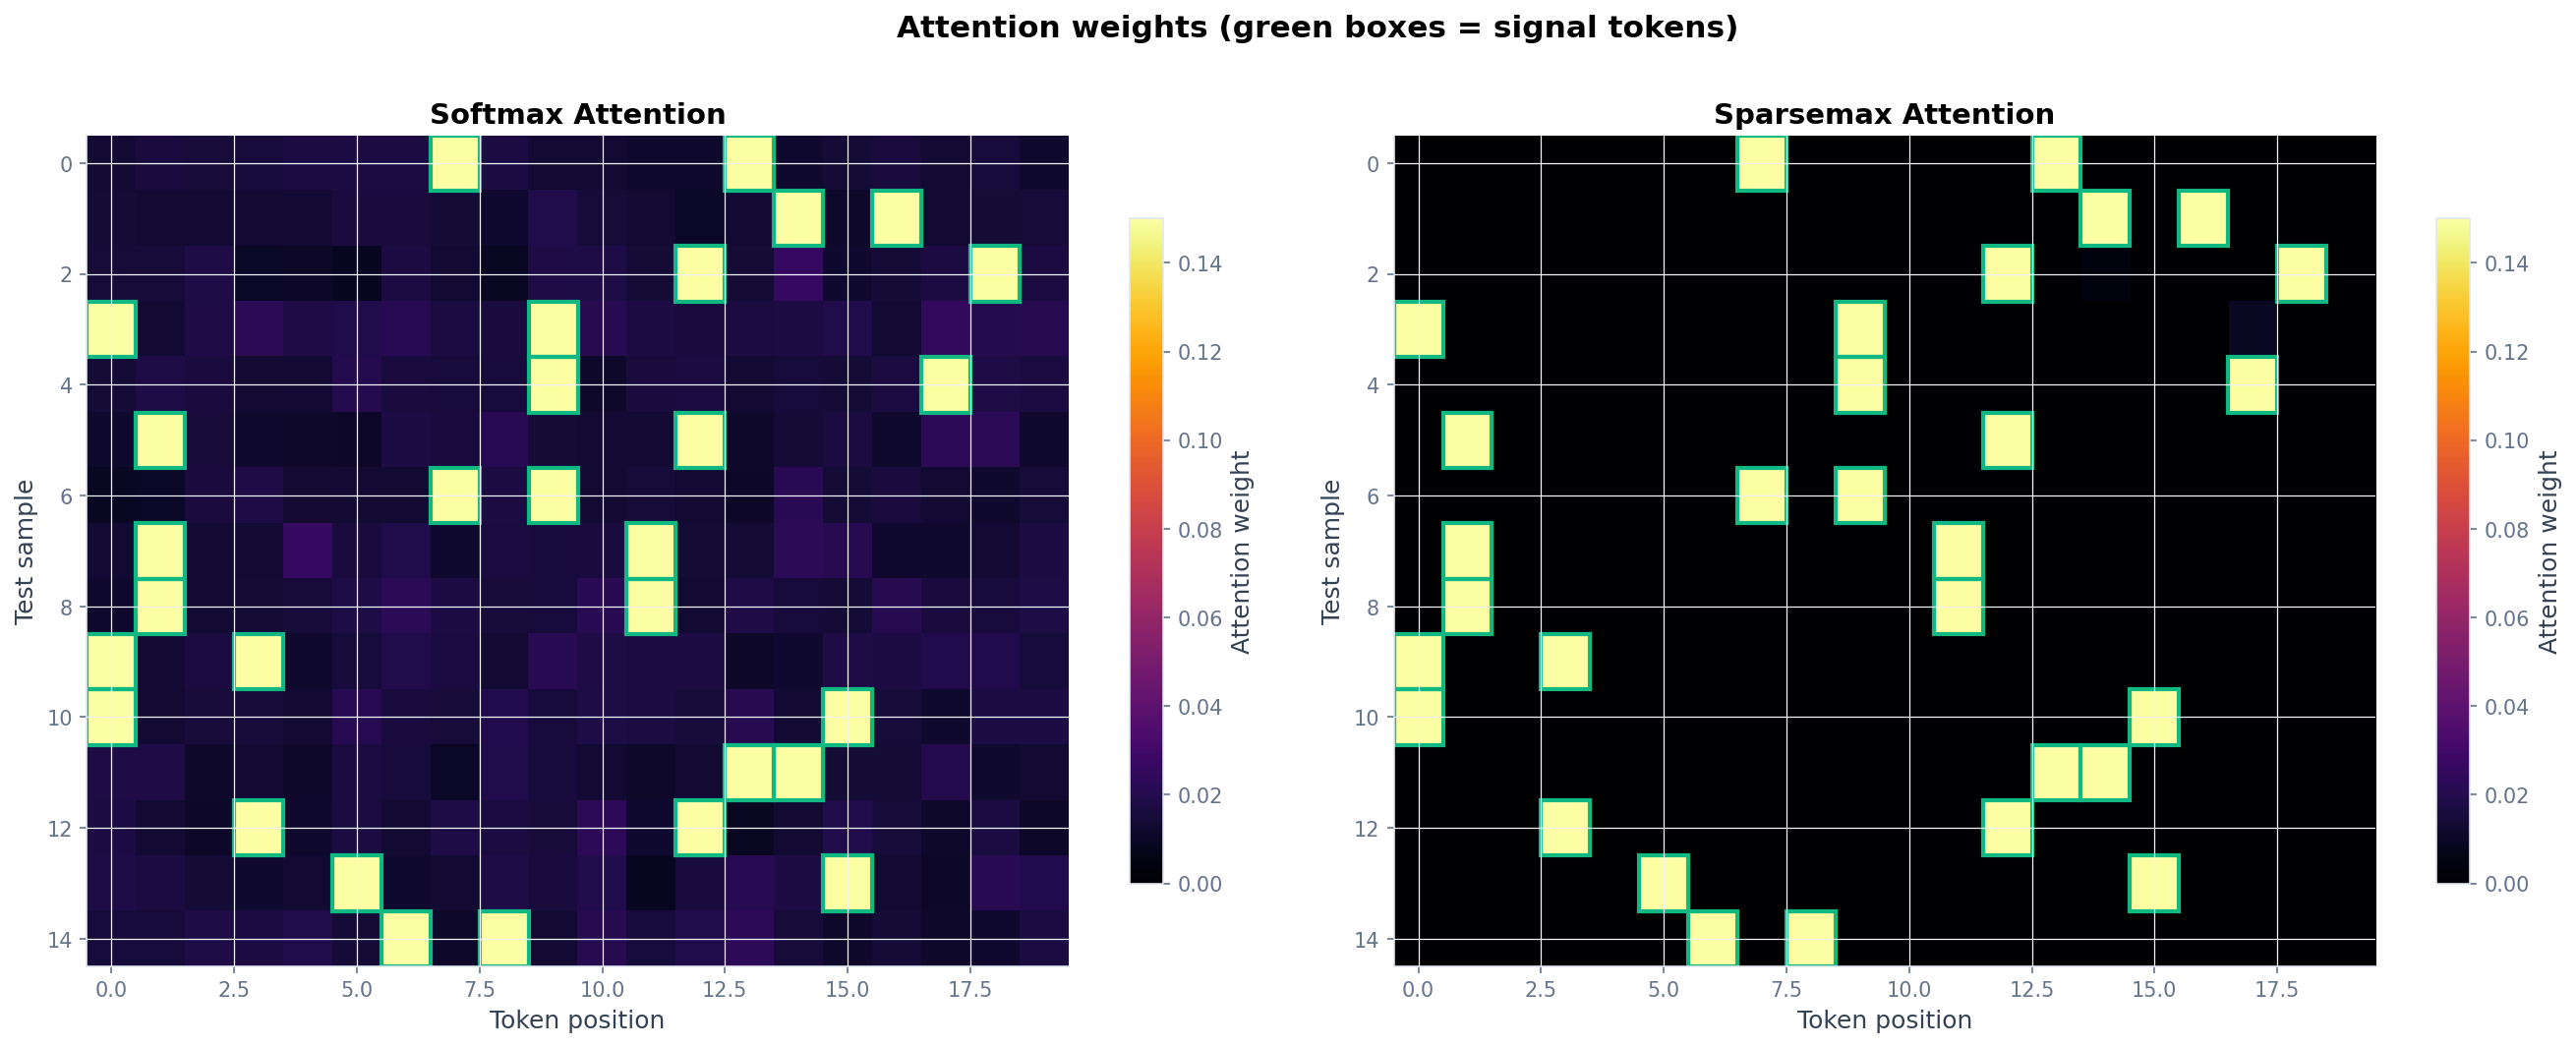

Softmax leaks attention to every token. Sparsemax zeros out noise completely.


In [9]:
# --- Side-by-side attention heatmaps ---
n_show = 15  # samples to display

# Use a LOW vmax so that softmax's ~5% noise attention is clearly visible,
# while sparsemax's exact zeros remain black.
vmax = 0.15

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, attn, title in [
    (axes[0], attn_soft[:n_show].numpy(), "Softmax Attention"),
    (axes[1], attn_sparse[:n_show].numpy(), "Sparsemax Attention"),
]:
    im = ax.imshow(attn, aspect="auto", cmap="inferno", vmin=0, vmax=vmax)
    # Mark signal positions with green squares
    for i in range(n_show):
        for j in range(n_tokens):
            if sig_test[i, j]:
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                     linewidth=2, edgecolor=MOREAU_COLORS["success"],
                                     facecolor="none")
                ax.add_patch(rect)
    ax.set_xlabel("Token position")
    ax.set_ylabel("Test sample")
    ax.set_title(title, fontsize=14)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Attention weight")

fig.suptitle("Attention weights (green boxes = signal tokens)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Softmax leaks attention to every token. Sparsemax zeros out noise completely.")

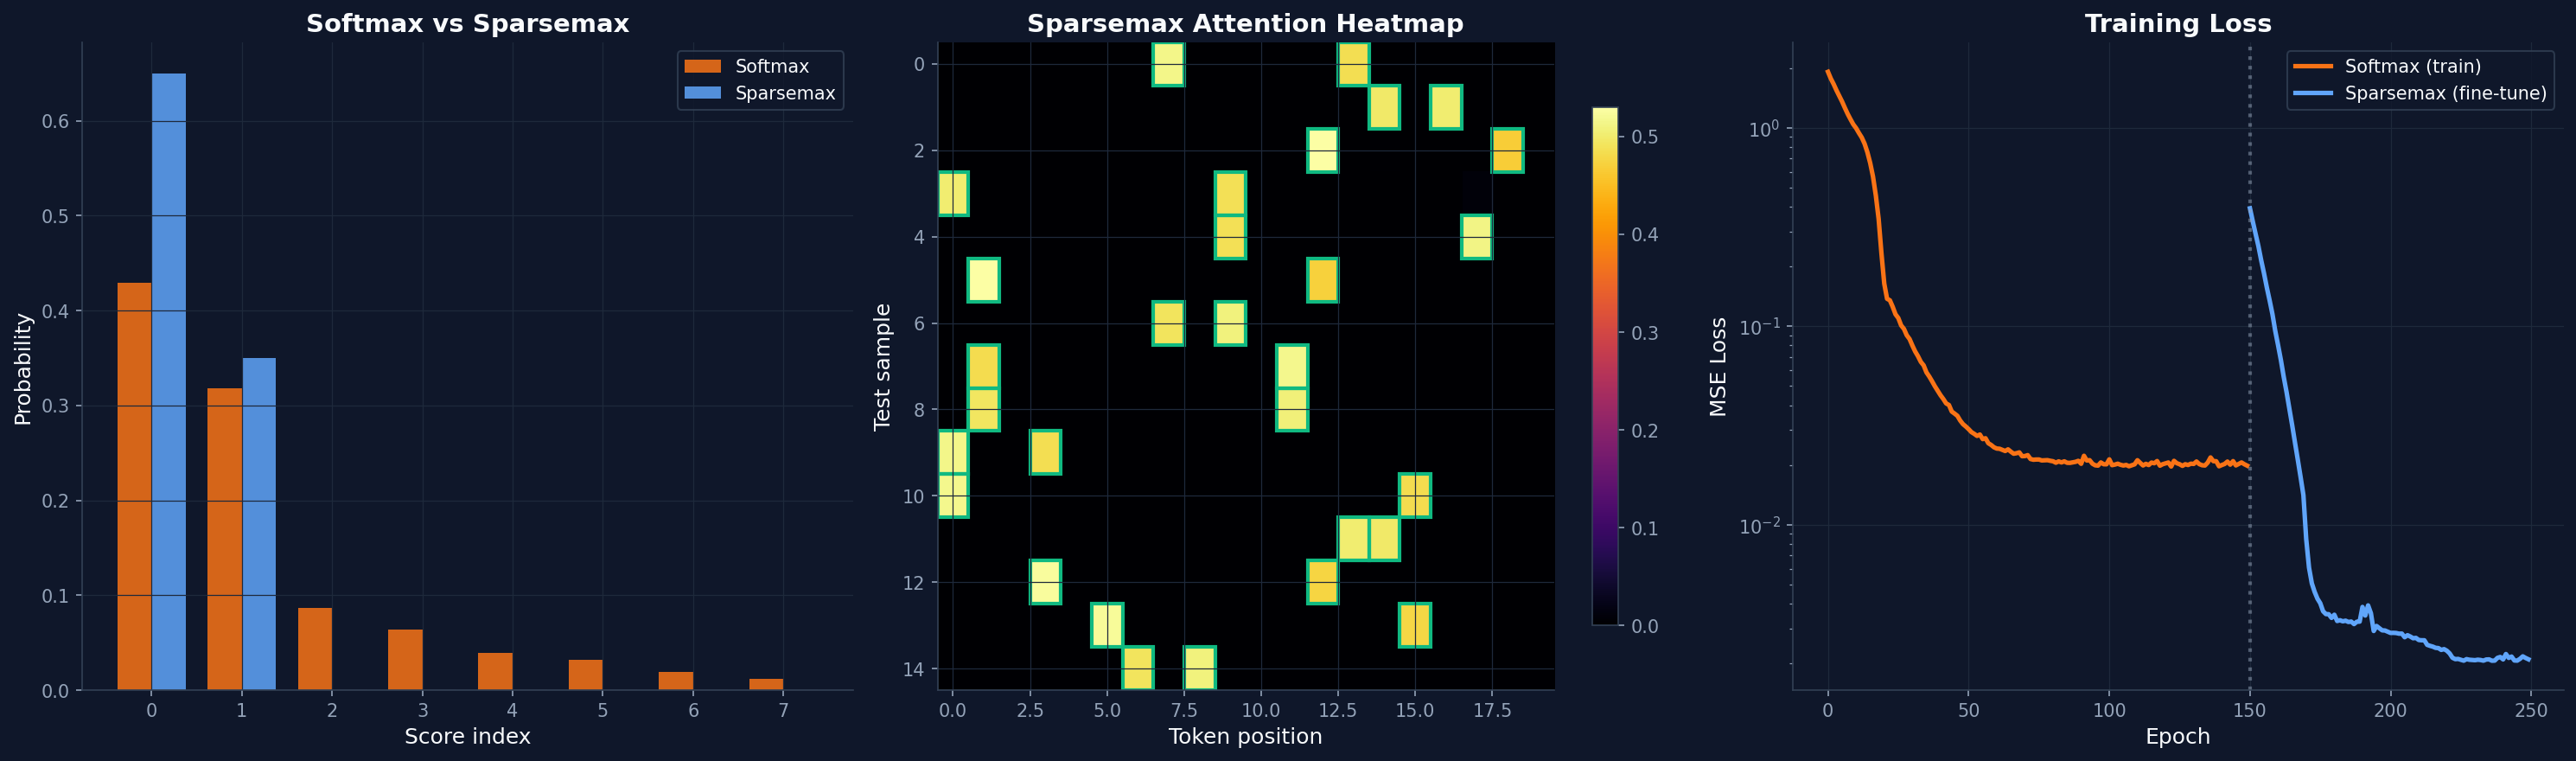

Saved hero image to ../assets/sparsemax_attention.png


In [10]:
# --- Hero image: dark, 3-panel ---
set_moreau_dark_style()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Softmax vs sparsemax probability bars (K=8, "Clear gap" regime from Part A)
ax = axes[0]
z_hero = np.array([2.1, 1.8, 0.5, 0.2, -0.3, -0.5, -1.0, -1.5])
p_soft_hero = np.exp(z_hero) / np.exp(z_hero).sum()
p_sparse_hero = np.maximum(p_sparsemax, 0)  # from the Part A solve

K_hero = len(z_hero)
x_pos = np.arange(K_hero)
w = 0.38
bars_sm = ax.bar(x_pos - w/2, p_soft_hero, w, color=MOREAU_COLORS["accent"],
                 alpha=0.85, label="Softmax")
bars_sp = ax.bar(x_pos + w/2, p_sparse_hero, w, color=MOREAU_COLORS["primary_light"],
                 alpha=0.85, label="Sparsemax")
for k, bar in enumerate(bars_sp):
    if p_sparse_hero[k] < 1e-6:
        bar.set_color("#334155")
        bar.set_alpha(0.3)
ax.set_xlabel("Score index")
ax.set_ylabel("Probability")
ax.set_title("Softmax vs Sparsemax", fontsize=14)
ax.set_xticks(x_pos)
ax.legend(loc="upper right", frameon=True, facecolor=MOREAU_COLORS["bg_dark"],
          edgecolor="#334155", fontsize=10)

# Panel 2: Sparsemax attention heatmap
ax = axes[1]
n_hero = 15
im = ax.imshow(attn_sparse[:n_hero].numpy(), aspect="auto", cmap="inferno",
               vmin=0, vmax=attn_sparse[:n_hero].numpy().max())
for i in range(n_hero):
    for j in range(n_tokens):
        if sig_test[i, j]:
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                 linewidth=2, edgecolor=MOREAU_COLORS["success"],
                                 facecolor="none")
            ax.add_patch(rect)
ax.set_xlabel("Token position")
ax.set_ylabel("Test sample")
ax.set_title("Sparsemax Attention Heatmap", fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8)

# Panel 3: Training loss curves (softmax training + sparsemax fine-tuning)
ax = axes[2]
ax.semilogy(losses_soft, color=MOREAU_COLORS["accent"], linewidth=2.5, label="Softmax (train)")
# Offset sparsemax losses to show as continuation
offset = len(losses_soft)
ax.semilogy(range(offset, offset + len(losses_sparse)),
            losses_sparse, color=MOREAU_COLORS["primary_light"], linewidth=2.5,
            label="Sparsemax (fine-tune)")
ax.axvline(offset, color=MOREAU_COLORS["text_secondary"], linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training Loss", fontsize=14)
ax.legend(loc="upper right", frameon=True, facecolor=MOREAU_COLORS["bg_dark"],
          edgecolor="#334155", fontsize=10)

plt.tight_layout()
plt.savefig("../assets/sparsemax_attention.png", bbox_inches="tight",
            facecolor=MOREAU_COLORS["bg_dark"])
plt.show()
set_moreau_style()
print("Saved hero image to ../assets/sparsemax_attention.png")

---

**Key takeaways:**

| | Softmax | Sparsemax |
|---|---|---|
| **Output** | Always dense — every token gets positive weight | Sparse — exact zeros for irrelevant tokens |
| **Formulation** | Closed-form $e^{z_k} / \sum e^{z_j}$ | Simplex projection: $\arg\min_{p \in \Delta^K} \|p - z\|^2$ |
| **Attention pattern** | Diffuse across all tokens | Concentrates on signal tokens |
| **Differentiability** | Built into PyTorch | `cvxpylayers` — wrap the CVXPY problem, Moreau handles forward + backward |

- **Sparsemax is a simplex projection** — a convex problem with a clean structure that Moreau solves efficiently
- **`cvxpylayers`** makes it a drop-in attention layer — define the problem in CVXPY, get auto-batched differentiability for free
- **Train dense, sparsify**: softmax trains the scorer, sparsemax fine-tuning sharpens attention to exact signal positions